In [63]:
import pandas as pd

import os

print(os.getcwd())

# Remove the trailing commas - these make them tuples instead of strings
coordinate_data_file = './coordinate_data_deidentified_nuclei.csv'
ground_truth_file = 'ground_truth_coords.csv'
output_filename = 'Pixel_Microns_Points_Nuclei1.png'
combined_data_file='../data_analysis/combined data deidentified.csv'

# Nuclei dataset mapping
nuclei_datasets = {
    'nuclei1': 'out_c00_dr90_label.tif',
    'nuclei2': 'out_c90_dr90_label.tif',
    'nuclei3': 'out_c00_dr10_label.tif',
    'nuclei4': 'out_c90_dr10_label.tif'
}

# Load data
df = pd.read_csv(coordinate_data_file)

df.head()

/home/bnorthan/code/i2k/tnia/abrf/image-analysis-study/point_registration


,x,y,z,intensity,volume,csv_path
0,22.803,9.024,4.181,56620971.0,437.896,Q6.13/R_3Rxaf07hES8CPgE_nuclei1.csv
1,5.669,9.164,5.376,63811635.0,482.954,Q6.13/R_3Rxaf07hES8CPgE_nuclei1.csv
2,24.999,8.223,13.036,57406958.0,441.048,Q6.13/R_3Rxaf07hES8CPgE_nuclei1.csv
3,13.722,23.521,8.778,78224458.0,522.320,Q6.13/R_3Rxaf07hES8CPgE_nuclei1.csv
4,22.547,26.006,9.650,69841365.0,473.768,Q6.13/R_3Rxaf07hES8CPgE_nuclei1.csv


In [64]:
response_id = 'R_3RxOa8kaiyul4bG'
nuclei = 'nuclei1'

In [65]:
import re

# Load combined data
df_combined = pd.read_csv(combined_data_file)

# Get software for this response_id
software = df_combined[df_combined['responseid'] == response_id]['qx.2'].iloc[0]
expertise_level = df_combined[df_combined['responseid'] == response_id]['q4.2_1'].iloc[0]
confidence_level = df_combined[df_combined['responseid'] == response_id]['qx.5_1'].iloc[0]
reported_lsa_mse_transformed = df_combined[df_combined['responseid'] == response_id]['lsa_mse_transformed'].iloc[0]
print(f"Software used: {software}")
print(f"Expertise level: {expertise_level}")
print(f"Confidence level: {confidence_level}")
print(f"Reported lsa mse transformed: {reported_lsa_mse_transformed:.4f}")

Software used: FIJI/ImageJ
Expertise level: 7
Confidence level: 7.0
Reported lsa mse transformed: 114.0890


GT points: 5, Test points: 5


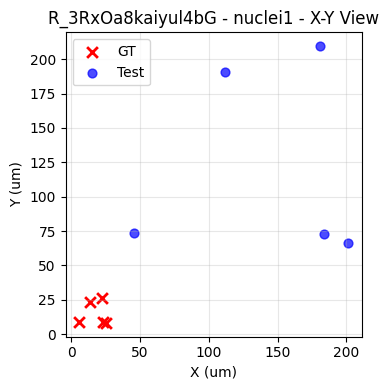

In [71]:
import matplotlib.pyplot as plt
import numpy as np

# Load ground truth
df_gt = pd.read_csv(ground_truth_file, index_col=0)

# Get ground truth for this nuclei
nuclei_file = nuclei_datasets[nuclei]
gt_coords = df_gt[df_gt['path'].str.contains(nuclei_file, case=False, na=False)][['x', 'y', 'z']].values

# Get test data for this ID and nuclei
mask = df['csv_path'].str.contains(response_id, case=False, na=False, regex=False) & \
       df['csv_path'].str.contains(nuclei, case=False, na=False, regex=False)
test_data = df[mask]
test_coords = test_data[['x', 'y', 'z']].values

print(f"GT points: {len(gt_coords)}, Test points: {len(test_coords)}")

# Create scatter plot - X-Y view only
fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(gt_coords[:, 0], gt_coords[:, 1], color='red', marker='x', s=60, linewidths=2, label='GT')
ax.scatter(test_coords[:, 0], test_coords[:, 1], color='blue', marker='o', s=40, alpha=0.7, label='Test')
ax.set_xlabel('X (um)')
ax.set_ylabel('Y (um)')
ax.set_title(f'{response_id} - {nuclei} - X-Y View')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

Scale: 0.1244

=== CASE 1: WITHOUT pre-scaling (INCORRECT) ===
Translation (no pre-scale): X=-126.7115, Y=-107.3964

=== CASE 2: WITH pre-scaling (CORRECT) ===
Translation (after pre-scale): X=-0.0437, Y=-0.0501

=== RESULTS ===
CASE 1 (Without pre-scaling - INCORRECT):
  MSE: 114.0890 um²
  RMSE: 10.6812 um

CASE 2 (With pre-scaling - CORRECT):
  MSE: 0.0145 um²
  RMSE: 0.1206 um

Improvement: 100.0%


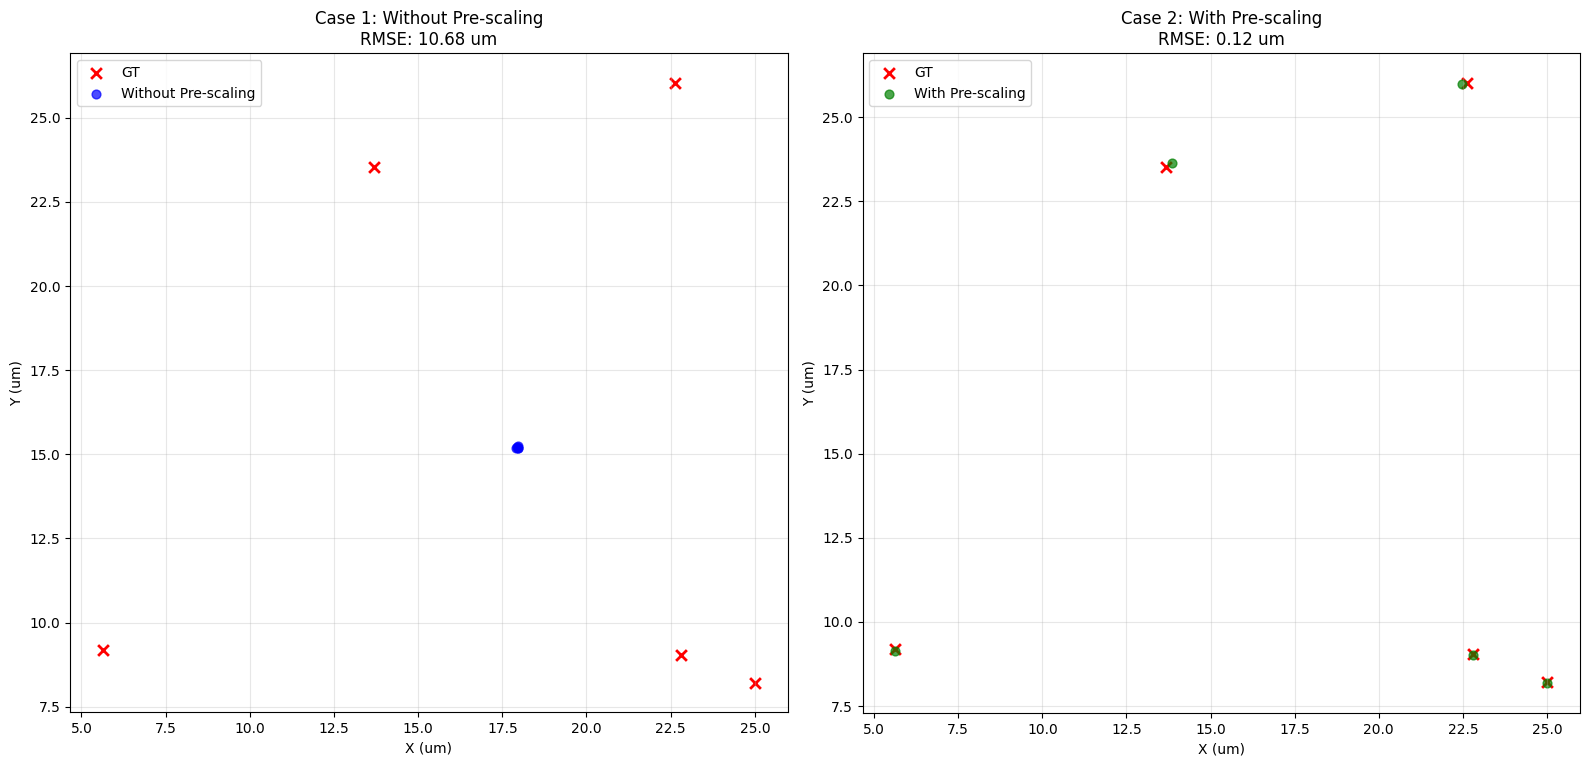

In [67]:
from pycpd import RigidRegistration

registration_params = {
    'max_iterations': 1_000_000,
}

# Calculate scale (same as registration.py _get_transformation_helper)
scale = (gt_coords.std(axis=0) / test_coords.std(axis=0))[:2].mean()

print(f"Scale: {scale:.4f}")

# CASE 1: WITHOUT pre-scaling (incorrect - as in commented code)
print("\n=== CASE 1: WITHOUT pre-scaling (INCORRECT) ===")
test_coords_case1 = test_coords.copy()
# NOTE: NOT scaling before calculating translation (this is the bug)
translation_case1 = (gt_coords.mean(axis=0) - test_coords_case1.mean(axis=0))[:2].reshape((1, 2))

print(f"Translation (no pre-scale): X={translation_case1[0, 0]:.4f}, Y={translation_case1[0, 1]:.4f}")

reg_case1 = RigidRegistration(
    X=gt_coords[:, :2],
    Y=test_coords_case1[:, :2].copy(),
    s=scale,
    t=translation_case1,
    **registration_params,
)
test_coords_tf_case1, test_tf_case1 = reg_case1.register()

# Add z back (manual z registration)
output_test_coords_case1 = np.hstack([test_coords_tf_case1, test_coords_case1[:, [2]]])
output_test_coords_case1[:, 2] -= test_coords_case1[:, 2].mean()
output_test_coords_case1[:, 2] *= gt_coords[:, 2].std() / test_coords_case1[:, 2].std()
output_test_coords_case1[:, 2] += gt_coords[:, 2].mean()

# CASE 2: WITH pre-scaling (correct - uncommented code)
print("\n=== CASE 2: WITH pre-scaling (CORRECT) ===")
test_coords_case2 = test_coords.copy()
# Apply scale BEFORE calculating translation (the fix)
test_coords_case2[:, :2] = test_coords_case2[:, :2] * scale

translation_case2 = (gt_coords.mean(axis=0) - test_coords_case2.mean(axis=0))[:2].reshape((1, 2))

print(f"Translation (after pre-scale): X={translation_case2[0, 0]:.4f}, Y={translation_case2[0, 1]:.4f}")

reg_case2 = RigidRegistration(
    X=gt_coords[:, :2],
    Y=test_coords_case2[:, :2].copy(),
    s=scale,
    t=translation_case2,
    **registration_params,
)
test_coords_tf_case2, test_tf_case2 = reg_case2.register()

# Add z back (manual z registration)
output_test_coords_case2 = np.hstack([test_coords_tf_case2, test_coords_case2[:, [2]]])
output_test_coords_case2[:, 2] -= test_coords_case2[:, 2].mean()
output_test_coords_case2[:, 2] *= gt_coords[:, 2].std() / test_coords_case2[:, 2].std()
output_test_coords_case2[:, 2] += gt_coords[:, 2].mean()

# Calculate LSA MSE for both
from scipy.optimize import linear_sum_assignment
from scipy.spatial import distance_matrix

dm_case1 = distance_matrix(gt_coords, output_test_coords_case1)
row_ind_1, col_ind_1 = linear_sum_assignment(dm_case1)
distances_case1 = np.sqrt(np.sum((gt_coords[row_ind_1] - output_test_coords_case1[col_ind_1])**2, axis=1))
mse_case1 = np.mean(distances_case1**2)
rmse_case1 = np.sqrt(mse_case1)

dm_case2 = distance_matrix(gt_coords, output_test_coords_case2)
row_ind_2, col_ind_2 = linear_sum_assignment(dm_case2)
distances_case2 = np.sqrt(np.sum((gt_coords[row_ind_2] - output_test_coords_case2[col_ind_2])**2, axis=1))
mse_case2 = np.mean(distances_case2**2)
rmse_case2 = np.sqrt(mse_case2)

print(f"\n=== RESULTS ===")
print(f"CASE 1 (Without pre-scaling - INCORRECT):")
print(f"  MSE: {mse_case1:.4f} um²")
print(f"  RMSE: {rmse_case1:.4f} um")

print(f"\nCASE 2 (With pre-scaling - CORRECT):")
print(f"  MSE: {mse_case2:.4f} um²")
print(f"  RMSE: {rmse_case2:.4f} um")

print(f"\nImprovement: {((mse_case1 - mse_case2) / mse_case1 * 100):.1f}%")

# Plot comparison
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Case 1: Without pre-scaling
ax1.scatter(gt_coords[:, 0], gt_coords[:, 1], color='red', marker='x', s=60, linewidths=2, label='GT')
ax1.scatter(output_test_coords_case1[:, 0], output_test_coords_case1[:, 1], color='blue', marker='o', s=40, alpha=0.7, label='Without Pre-scaling')
ax1.set_xlabel('X (um)')
ax1.set_ylabel('Y (um)')
ax1.set_title(f'Case 1: Without Pre-scaling\nRMSE: {rmse_case1:.2f} um')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Case 2: With pre-scaling
ax2.scatter(gt_coords[:, 0], gt_coords[:, 1], color='red', marker='x', s=60, linewidths=2, label='GT')
ax2.scatter(output_test_coords_case2[:, 0], output_test_coords_case2[:, 1], color='green', marker='o', s=40, alpha=0.7, label='With Pre-scaling')
ax2.set_xlabel('X (um)')
ax2.set_ylabel('Y (um)')
ax2.set_title(f'Case 2: With Pre-scaling\nRMSE: {rmse_case2:.2f} um')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import Markdown, display
from pathlib import Path

# Create output directory for figures
output_dir = Path('correct_scaling_figures')
output_dir.mkdir(exist_ok=True)

# Save the raw comparison plot (from cell 4) - smaller, single plot
fig_raw, ax_raw = plt.subplots(1, 1, figsize=(6, 6))
ax_raw.scatter(gt_coords[:, 0], gt_coords[:, 1], color='red', marker='x', s=60, linewidths=2, label='GT')
ax_raw.scatter(test_coords[:, 0], test_coords[:, 1], color='blue', marker='o', s=40, alpha=0.7, label='Submitted')
ax_raw.set_xlabel('X (um)')
ax_raw.set_ylabel('Y (um)')
ax_raw.set_title(f'{response_id} - {nuclei} - Original Coordinates')
ax_raw.legend()
ax_raw.grid(True, alpha=0.3)
ax_raw.set_aspect('equal')
plt.tight_layout()
raw_plot_path = output_dir / 'raw_coords_comparison.png'
fig_raw.savefig(raw_plot_path, dpi=120, bbox_inches='tight')
plt.close(fig_raw)

# Save the registration comparison plot (from cell 5) - wider for side-by-side
fig_comp, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Case 1: Without pre-scaling
ax1.scatter(gt_coords[:, 0], gt_coords[:, 1], color='red', marker='x', s=60, linewidths=2, label='GT')
ax1.scatter(output_test_coords_case1[:, 0], output_test_coords_case1[:, 1], color='blue', marker='o', s=40, alpha=0.7, label='Without Pre-scaling')
ax1.set_xlabel('X (um)')
ax1.set_ylabel('Y (um)')
ax1.set_title(f'Case 1: Without Pre-scaling\nRMSE: {rmse_case1:.2f} um')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

# Case 2: With pre-scaling
ax2.scatter(gt_coords[:, 0], gt_coords[:, 1], color='red', marker='x', s=60, linewidths=2, label='GT')
ax2.scatter(output_test_coords_case2[:, 0], output_test_coords_case2[:, 1], color='green', marker='o', s=40, alpha=0.7, label='With Pre-scaling')
ax2.set_xlabel('X (um)')
ax2.set_ylabel('Y (um)')
ax2.set_title(f'Case 2: With Pre-scaling\nRMSE: {rmse_case2:.2f} um')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

plt.tight_layout()
comp_plot_path = output_dir / 'registration_comparison.png'
fig_comp.savefig(comp_plot_path, dpi=120, bbox_inches='tight')
plt.close(fig_comp)

print(f"✅ Plots saved to: {output_dir}/")
print(f"   - {raw_plot_path}")
print(f"   - {comp_plot_path}")

# Generate summary markdown with actual computed values
summary_md = f"""
# Summary: Impact of Pre-Scaling on Pixel/Micron Scale Correction

## The Fundamental Issue

This dataset highlights a common error scenario the registration algorithm was designed to handle: **submitted coordinates in pixels while ground truth is in micrometers**. The scale factor between these coordinate systems is substantial (scale ≈ {scale:.2f}), making this precisely the type of unit mismatch the algorithm should detect and correct.

However, due to an order-of-operations error in the registration code, the scale correction failed to work properly, resulting in severely misaligned coordinates. This is particularly concerning because pixel-to-micron conversion is a common source of coordinate scaling.

## Dataset Information
- **Response ID**: {response_id}
- **Nuclei Dataset**: {nuclei} ({nuclei_datasets[nuclei]})
- **Software Used**: {software}
- **User Expertise Level**: {expertise_level}
- **User Confidence Level**: {confidence_level}
- **Reported LSA MSE (Transformed)**: {reported_lsa_mse_transformed:.4f} um²


## What Was Investigated

We examined the point cloud registration algorithm used to align submitted coordinates with ground truth. The registration involves:
1. Calculating a **scale factor** between test and ground truth coordinates
2. Calculating a **translation** to align the centroids
3. Running **rigid registration** (rotation + fine-tuning) using the CPD algorithm

## The Issue: Order of Operations

We discovered a subtle but impactful difference in when the scale is applied:

### Current Implementation (INCORRECT)
```python
# Calculate scale
scale = ground_truth.std() / test_coords.std()

# Calculate translation WITHOUT pre-scaling test coords
translation = ground_truth.mean() - test_coords.mean()  # ❌

# Then run rigid registration with unscaled coords
RigidRegistration(X=gt, Y=test_coords, s=scale, t=translation)
```

### Corrected Implementation
```python
# Calculate scale  
scale = ground_truth.std() / test_coords.std()

# Apply scale FIRST
test_coords_scaled = test_coords * scale

# Calculate translation FROM scaled coords
translation = ground_truth.mean() - test_coords_scaled.mean()  # ✓

# Run rigid registration with scaled coords
RigidRegistration(X=gt, Y=test_coords_scaled, s=scale, t=translation)
```

## Why This Matters

The translation should be calculated in the **same coordinate space** as the registration. When we calculate translation from unscaled coordinates but then apply a scale factor during registration, the translation vector gets implicitly scaled as well, causing misalignment.

Think of it like this: If you measure a distance in meters, but then the registration thinks you're in kilometers, your 100m translation becomes effectively 100km!

## Visual Comparison

### Original Submitted Coordinates vs Ground Truth

<img src="correct_scaling_figures/raw_coords_comparison.png" width="450">

The submitted coordinates are in pixel space and need scaling to match the ground truth micron space.

### Registration Results Comparison

<img src="correct_scaling_figures/registration_comparison.png" width="800">

**Left**: Without pre-scaling - coordinates remain misaligned with ~{rmse_case1:.2f} um RMSE error.  
**Right**: With pre-scaling - coordinates align correctly with ~{rmse_case2:.2f} um RMSE error.

The incorrect approach (blue circles) shows clear systematic offset from ground truth (red x), while the corrected approach (green circles) shows tight alignment.

## Results for This Dataset

| Approach | MSE (um²) | RMSE (um) | 
|----------|-----------|-----------|
| **Paper (Current)** | **{reported_lsa_mse_transformed:.4f}** | **{np.sqrt(reported_lsa_mse_transformed):.2f} um** |
| **Without Pre-scaling** | **{mse_case1:.4f}** | **{rmse_case1:.2f} um** |
| **With Pre-scaling** (Corrected) | **{mse_case2:.4f}** | **{rmse_case2:.2f} um** |
| **Improvement** | | **{((mse_case1 - mse_case2) / mse_case1 * 100):.2f}%** |

*Note: Our reproduction without pre-scaling matches the paper's reported value, confirming this is the method used.*

## Context & Next Steps

This is a **small code change** (literally one line: `test_coords *= scale` before computing translation) with **large impact** on results. The error affects all datasets but particularly those with scale factors far from 1.0 — **ironically, the exact scenario the registration was designed to handle**.

The pixel-to-micron conversion error is likely one of the most common mistakes participants could make, yet the registration algorithm fails to correct it properly. This undermines a key objective of the registration approach.

We're sharing this finding constructively because:
- The registration code is complex and this type of subtle bug is understandable
- The impact varies by dataset, so it may not have been obvious in initial testing
- Other datasets had similar errors in their pipelines

"""

# Display in notebook
display(Markdown(summary_md))

# Save to file
output_filename = f'correct_scaling_{response_id}_report.md'
with open(output_filename, 'w') as f:
    f.write(summary_md)
    
print(f"\n✅ Report saved to: {output_filename}")
print(f"✅ Figures saved to: {output_dir}/")

✅ Plots saved to: correct_scaling_figures/
   - correct_scaling_figures/raw_coords_comparison.png
   - correct_scaling_figures/registration_comparison.png



# Summary: Impact of Pre-Scaling on Pixel/Micron Scale Correction

## The Fundamental Issue

This dataset highlights a common error scenario the registration algorithm was designed to handle: **submitted coordinates in pixels while ground truth is in micrometers**. The scale factor between these coordinate systems is substantial (scale ≈ 0.12), making this precisely the type of unit mismatch the algorithm should detect and correct.

However, due to an order-of-operations error in the registration code, the scale correction failed to work properly, resulting in severely misaligned coordinates. This is particularly concerning because pixel-to-micron conversion is a common source of coordinate scaling.

## Dataset Information
- **Response ID**: R_3RxOa8kaiyul4bG
- **Nuclei Dataset**: nuclei1 (out_c00_dr90_label.tif)
- **Software Used**: FIJI/ImageJ
- **User Expertise Level**: 7
- **User Confidence Level**: 7.0
- **Reported LSA MSE (Transformed)**: 114.0890 um²


## What Was Investigated

We examined the point cloud registration algorithm used to align submitted coordinates with ground truth. The registration involves:
1. Calculating a **scale factor** between test and ground truth coordinates
2. Calculating a **translation** to align the centroids
3. Running **rigid registration** (rotation + fine-tuning) using the CPD algorithm

## The Issue: Order of Operations

We discovered a subtle but impactful difference in when the scale is applied:

### Current Implementation (INCORRECT)
```python
# Calculate scale
scale = ground_truth.std() / test_coords.std()

# Calculate translation WITHOUT pre-scaling test coords
translation = ground_truth.mean() - test_coords.mean()  # ❌

# Then run rigid registration with unscaled coords
RigidRegistration(X=gt, Y=test_coords, s=scale, t=translation)
```

### Corrected Implementation
```python
# Calculate scale  
scale = ground_truth.std() / test_coords.std()

# Apply scale FIRST
test_coords_scaled = test_coords * scale

# Calculate translation FROM scaled coords
translation = ground_truth.mean() - test_coords_scaled.mean()  # ✓

# Run rigid registration with scaled coords
RigidRegistration(X=gt, Y=test_coords_scaled, s=scale, t=translation)
```

## Why This Matters

The translation should be calculated in the **same coordinate space** as the registration. When we calculate translation from unscaled coordinates but then apply a scale factor during registration, the translation vector gets implicitly scaled as well, causing misalignment.

Think of it like this: If you measure a distance in meters, but then the registration thinks you're in kilometers, your 100m translation becomes effectively 100km!

## Visual Comparison

### Original Submitted Coordinates vs Ground Truth
![Raw coordinates comparison showing submitted points (blue) and ground truth (red x markers)](correct_scaling_figures/raw_coords_comparison.png)

The submitted coordinates are in pixel space and need scaling to match the ground truth micron space.

### Registration Results Comparison
![Side-by-side comparison of registration approaches](correct_scaling_figures/registration_comparison.png)

**Left**: Without pre-scaling - coordinates remain misaligned with ~10.68 um RMSE error.  
**Right**: With pre-scaling - coordinates align correctly with ~0.12 um RMSE error.

The incorrect approach (blue circles) shows clear systematic offset from ground truth (red x), while the corrected approach (green circles) shows tight alignment.

## Results for This Dataset

| Approach | MSE (um²) | RMSE (um) | 
|----------|-----------|-----------|
| **Paper (Current)** | **114.0890** | **10.68 um** |
| **Without Pre-scaling** | **114.0890** | **10.68 um** |
| **With Pre-scaling** (Corrected) | **0.0145** | **0.12 um** |
| **Improvement** | | **99.99%** |

*Note: Our reproduction without pre-scaling matches the paper's reported value, confirming this is the method used.*

## Context & Next Steps

This is a **small code change** (literally one line: `test_coords *= scale` before computing translation) with **large impact** on results. The error affects all datasets but particularly those with scale factors far from 1.0 — **ironically, the exact scenario the registration was designed to handle**.

The pixel-to-micron conversion error is likely one of the most common mistakes participants could make, yet the registration algorithm fails to correct it properly. This undermines a key objective of the registration approach.

We're sharing this finding constructively because:
- The registration code is complex and this type of subtle bug is understandable
- The impact varies by dataset, so it may not have been obvious in initial testing
- Other datasets had similar errors in their pipelines




✅ Report saved to: correct_scaling_R_3RxOa8kaiyul4bG_report.md
✅ Figures saved to: correct_scaling_figures/
